<h2>Exercise 06: Scatter Matrix</h2>

In [1]:
import pandas as pd 
import sqlite3
from pandas.plotting import scatter_matrix

In [2]:
# import sys
# !{sys.executable} -m pip install --upgrade --force-reinstall pandas

# !pip uninstall pandas -y
# !pip install pandas==2.2.2

### Preprocessing

In [3]:
df_csv = pd.read_csv("../data/ab-test.csv")
conn = sqlite3.connect("../data/checking-logs.sqlite")

In [4]:
df_checker = pd.io.sql.read_sql(
    """
    SELECT 
        *
    FROM checker
    WHERE uid LIKE "user_%" and labname NOT LIKE "project1"
    """,
    conn
)

df_checker

,index,status,success,timestamp,numTrials,labname,uid
0,21,ready,0,2020-04-17 11:33:17.366400,1,laba04,user_4
1,22,checking,0,2020-04-17 11:40:05.103116,2,laba04,user_4
2,23,ready,0,2020-04-17 11:40:05.237273,2,laba04,user_4
3,24,checking,0,2020-04-17 11:44:20.541374,3,laba04,user_4
4,25,ready,1,2020-04-17 11:44:20.707058,3,laba04,user_4
...,...,...,...,...,...,...,...
1307,3397,ready,0,2020-05-21 20:19:06.872761,7,laba06s,user_1
1308,3398,checking,0,2020-05-21 20:22:41.785725,8,laba06s,user_1
1309,3399,ready,0,2020-05-21 20:22:41.877806,8,laba06s,user_1
1310,3400,checking,0,2020-05-21 20:37:00.129678,9,laba06s,user_1


In [5]:
df_pageviews = pd.io.sql.read_sql(
    """
    SELECT 
        *
    FROM pageviews
    WHERE uid LIKE "user_%"
    """,
    conn
)
df_pageviews

,index,uid,datetime
0,12,user_30,2020-04-17 22:46:26.785035
1,14,user_14,2020-04-18 10:53:52.623447
2,15,user_17,2020-04-18 10:56:55.833899
3,16,user_14,2020-04-18 10:57:37.331258
4,18,user_17,2020-04-18 12:05:48.200144
...,...,...,...
982,1073,user_28,2020-05-21 18:45:20.441142
983,1074,user_19,2020-05-21 23:03:06.457819
984,1075,user_25,2020-05-21 23:23:49.995349
985,1078,user_5,2020-05-22 11:30:18.368990


In [6]:
df_dealines = pd.io.sql.read_sql(
    """
    SELECT
        *
    FROM deadlines
    WHERE labs != "project1"
    """,
    conn,
    parse_dates=["deadlines"]
)

df_dealines.rename(columns={"labs": "labname"}, inplace=True)
df_dealines.drop('index', inplace=True, axis='columns')
df_dealines

,labname,deadlines
0,laba04,2020-04-26 23:59:59
1,laba04s,2020-04-26 23:59:59
2,laba05,2020-05-03 23:59:59
3,laba06,2020-05-24 23:59:59
4,laba06s,2020-05-24 23:59:59


In [7]:
df_csv

,uid,diff,time,group
0,user_1,-103.333333,after,test
1,user_1,-6.000000,before,test
2,user_18,-10.000000,after,test
3,user_18,-3.500000,before,test
4,user_19,-82.333333,after,test
5,user_19,-148.000000,before,test
6,user_21,-78.500000,after,test
7,user_21,-112.500000,before,test
8,user_25,-127.500000,after,test
9,user_25,-69.333333,before,test


In [8]:
min_commit_time = df_checker.groupby(['uid', 'labname'])['timestamp'].min().reset_index()
min_commit_time

,uid,labname,timestamp
0,user_0,lab02,2020-04-20 17:56:45.209722
1,user_1,code_rvw,2020-04-26 19:06:58.949373
2,user_1,lab05s,2020-05-03 20:27:06.316718
3,user_1,laba04,2020-04-26 17:06:18.462708
4,user_1,laba04s,2020-04-26 17:12:11.843671
...,...,...,...
146,user_8,laba04,2020-04-18 21:53:36.058389
147,user_8,laba04s,2020-04-19 10:22:35.761944
148,user_8,laba05,2020-05-02 13:28:07.705193
149,user_8,laba06,2020-05-16 17:56:15.755553


In [9]:
diff = pd.merge(min_commit_time, df_dealines, on='labname', how='left')
# Привести timestamp к datetime, если еще не
diff['timestamp'] = pd.to_datetime(diff['timestamp'])
# Привести deadlines к datetime
diff['deadlines'] = pd.to_datetime(diff['deadlines'])
diff['diff'] = (diff['timestamp'] - diff['deadlines']) / pd.Timedelta(hours=1)
diff.dropna(inplace=True)
diff

,uid,labname,timestamp,deadlines,diff
3,user_1,laba04,2020-04-26 17:06:18.462708,2020-04-26 23:59:59,-6.894594
4,user_1,laba04s,2020-04-26 17:12:11.843671,2020-04-26 23:59:59,-6.796432
5,user_1,laba05,2020-05-02 19:15:18.540185,2020-05-03 23:59:59,-28.744572
6,user_1,laba06,2020-05-17 16:26:35.268534,2020-05-24 23:59:59,-175.556592
7,user_1,laba06s,2020-05-20 12:23:37.289724,2020-05-24 23:59:59,-107.606031
...,...,...,...,...,...
146,user_8,laba04,2020-04-18 21:53:36.058389,2020-04-26 23:59:59,-194.106373
147,user_8,laba04s,2020-04-19 10:22:35.761944,2020-04-26 23:59:59,-181.623122
148,user_8,laba05,2020-05-02 13:28:07.705193,2020-05-03 23:59:59,-34.530915
149,user_8,laba06,2020-05-16 17:56:15.755553,2020-05-24 23:59:59,-198.062012


In [10]:
mean_diff = diff.groupby("uid")["diff"].mean().reset_index()
mean_diff.rename(columns={"diff":"avg_diff"}, inplace=True)
mean_diff

,uid,avg_diff
0,user_1,-65.119644
1,user_10,-75.242310
2,user_11,-2.884175
3,user_12,-89.450688
4,user_13,-48.878198
5,user_14,-159.568696
6,user_15,-18.092892
7,user_16,-39.336201
8,user_17,-62.207513
9,user_18,-6.367907


In [11]:
df_csv_test = df_csv[df_csv["group"]=="test"]
df_test = df_csv_test.groupby("uid")["diff"].mean().reset_index(name='mean_diff')
df_test_t = df_test["uid"]

In [12]:
stats_checker = df_checker.groupby("uid").size().reset_index(name="commits")
stats_checker

,uid,commits
0,user_0,3
1,user_1,62
2,user_10,20
3,user_11,7
4,user_12,86
5,user_13,52
6,user_14,61
7,user_15,23
8,user_16,41
9,user_17,51


In [13]:
stats_views = df_pageviews.groupby("uid").size().reset_index(name="pageviews")
stats_views

,uid,pageviews
0,user_1,28
1,user_10,89
2,user_14,143
3,user_17,47
4,user_18,3
5,user_19,16
6,user_21,10
7,user_25,179
8,user_28,149
9,user_3,317


In [14]:
result = pd.merge(df_test_t, mean_diff, on="uid", how="left")
result = pd.merge(result, stats_views, on="uid", how="left")
result = pd.merge(result, stats_checker, on="uid", how="left")
result

,uid,avg_diff,pageviews,commits
0,user_1,-65.119644,28,62
1,user_18,-6.367907,3,5
2,user_19,-99.440298,16,118
3,user_21,-96.111041,10,65
4,user_25,-93.474751,179,79
5,user_28,-86.793652,149,60
6,user_3,-105.738041,317,18


### Result

In [15]:
# !pip install scipy

array([[<Axes: xlabel='avg_diff', ylabel='avg_diff'>,
        <Axes: xlabel='pageviews', ylabel='avg_diff'>,
        <Axes: xlabel='commits', ylabel='avg_diff'>],
       [<Axes: xlabel='avg_diff', ylabel='pageviews'>,
        <Axes: xlabel='pageviews', ylabel='pageviews'>,
        <Axes: xlabel='commits', ylabel='pageviews'>],
       [<Axes: xlabel='avg_diff', ylabel='commits'>,
        <Axes: xlabel='pageviews', ylabel='commits'>,
        <Axes: xlabel='commits', ylabel='commits'>]], dtype=object)

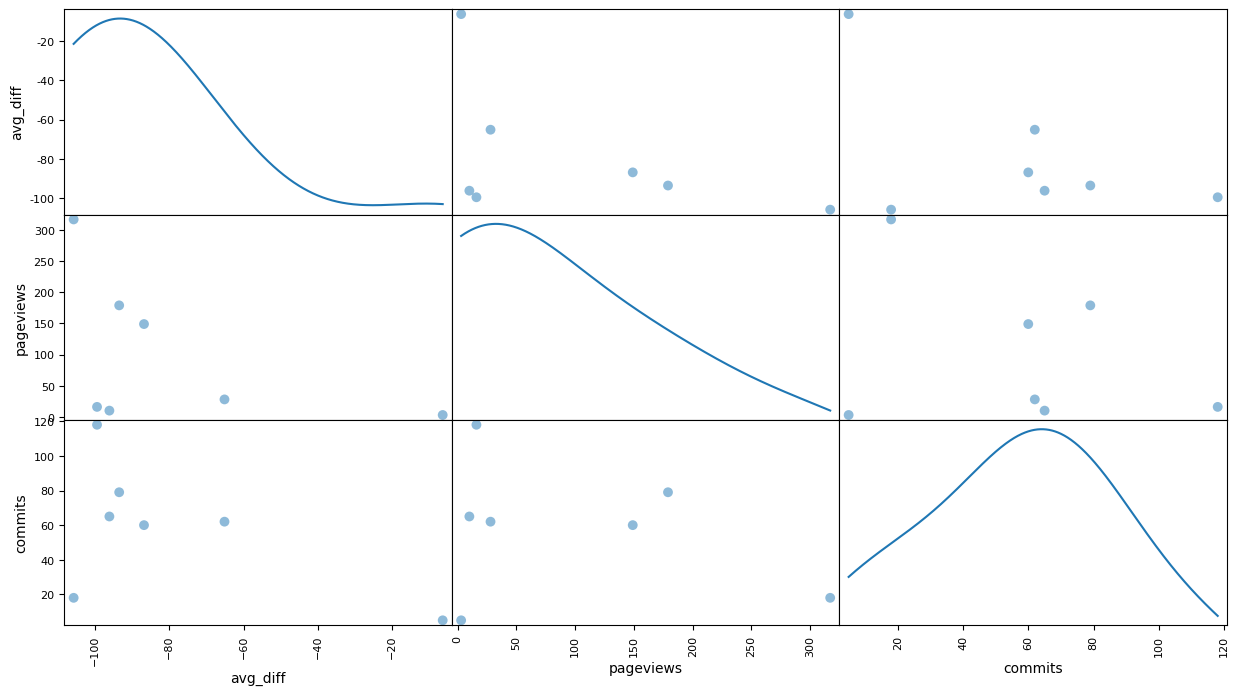

In [16]:
scatter_matrix(result, diagonal='kde', figsize=(15, 8), s=200, linewidth=3)

<h2>Answer</h2>
<h2>1. No</h2>
<h2>2. NO</h2>
<h2>3. Yes</h2>
<h2>4. No</h2>

In [17]:
conn.close()